# Gradient Descent from Scratch: Predicting Marks from Study Hours

**Goal:** understand how machines *learn* by building gradient descent by hand for linear regression, then checking it against scikit-learn.

**What this notebook covers**
1. The problem and the data
2. The exact answer (scikit-learn and the normal equation)
3. Gradient descent from scratch (learning both `m` and `b`)
4. Experiment 1: learning rate (too small / appropriate / too large)
5. Experiment 2: number of iterations
6. Feature scaling and why it matters
7. Conclusions and link to modern AI

## 1. The problem

A student's marks depend on hours studied. We want the line

$$\hat{y} = m x + b$$

that fits the data best. Guessing `m` and `b` randomly is unlikely to work, so we define a **loss** (mean squared error) and use **gradient descent** to adjust `m` and `b` until the loss is as small as possible:

$$L(m,b) = \frac{1}{n}\sum_{i}(y_i - (m x_i + b))^2$$

The gradients (derivatives of the loss) are:

$$\frac{\partial L}{\partial m} = -\frac{2}{n}\sum x_i\,(y_i - \hat{y}_i) \qquad \frac{\partial L}{\partial b} = -\frac{2}{n}\sum (y_i - \hat{y}_i)$$

Update rule (`lr` is the learning rate):

$$m \leftarrow m - lr\cdot\frac{\partial L}{\partial m} \qquad b \leftarrow b - lr\cdot\frac{\partial L}{\partial b}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.3})

## 2. The data

This is **synthetic** data: marks follow a true line (`marks = 12 + 7.5 * hours`) plus random noise, so we know roughly what the algorithm should find.

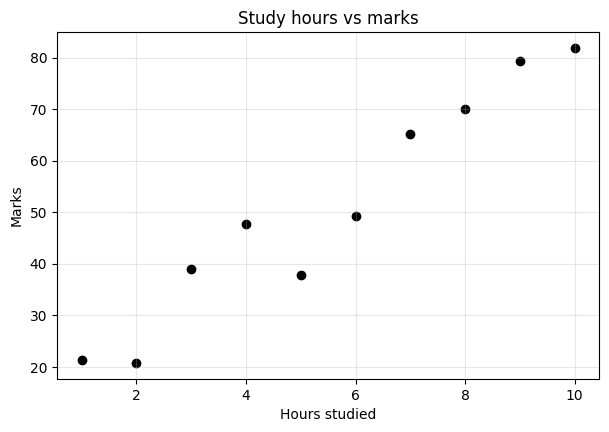

In [2]:
rng = np.random.default_rng(42)
hours = np.arange(1, 11, dtype=float)
marks = 12 + 7.5 * hours + rng.normal(0, 6, size=hours.size)

plt.scatter(hours, marks, color="black")
plt.xlabel("Hours studied"); plt.ylabel("Marks")
plt.title("Study hours vs marks")
plt.show()

## 3. The exact answer (our benchmark)

`LinearRegression` does **not** use gradient descent. It solves the problem directly with linear algebra (Ordinary Least Squares). We use its answer as the target our gradient descent should approach.

The normal equation gives the same result: $w = (X^TX)^{-1}X^Ty$.

In [3]:
reg = LinearRegression().fit(hours.reshape(-1, 1), marks)
m_sk, b_sk = reg.coef_[0], reg.intercept_

# Normal equation by hand (using lstsq, the numerically stable way)
A = np.column_stack([hours, np.ones_like(hours)])
m_ne, b_ne = np.linalg.lstsq(A, marks, rcond=None)[0]

print(f"sklearn LinearRegression : m = {m_sk:.4f}, b = {b_sk:.4f}")
print(f"Normal equation          : m = {m_ne:.4f}, b = {b_ne:.4f}")

sklearn LinearRegression : m = 7.1225, b = 12.0626
Normal equation          : m = 7.1225, b = 12.0626


## 4. Gradient descent from scratch

One function that learns **both** `m` and `b`, and records the loss and parameters at every step so we can study the behaviour.

In [4]:
def gradient_descent(x, y, lr=0.01, epochs=1000, m0=0.0, b0=0.0):
    m, b = m0, b0
    history = {"loss": [], "m": [], "b": []}
    for _ in range(epochs):
        error = y - (m * x + b)
        history["loss"].append(np.mean(error ** 2))
        history["m"].append(m)
        history["b"].append(b)

        dm = -2 * np.mean(x * error)
        db = -2 * np.mean(error)
        m -= lr * dm
        b -= lr * db
    return m, b, history

m_gd, b_gd, hist = gradient_descent(hours, marks, lr=0.01, epochs=2000)

print(f"Gradient descent : m = {m_gd:.4f}, b = {b_gd:.4f}")
print(f"sklearn          : m = {m_sk:.4f}, b = {b_sk:.4f}")

Gradient descent : m = 7.1229, b = 12.0603
sklearn          : m = 7.1225, b = 12.0626


### How the line moves toward the best fit

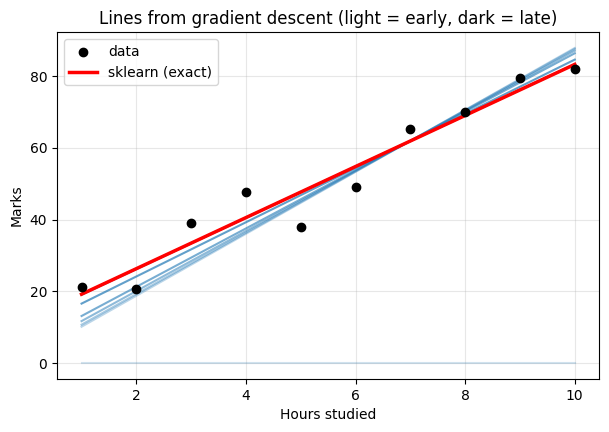

In [5]:
fig, ax = plt.subplots()
ax.scatter(hours, marks, color="black", zorder=3, label="data")

steps = [0, 5, 20, 50, 100, 300, 1000, 1999]
for k, s in enumerate(steps):
    ax.plot(hours, hist["m"][s] * hours + hist["b"][s],
            color="tab:blue", alpha=0.2 + 0.8 * k / len(steps))
ax.plot(hours, m_sk * hours + b_sk, color="red", lw=2.5, label="sklearn (exact)")
ax.set_xlabel("Hours studied"); ax.set_ylabel("Marks")
ax.set_title("Lines from gradient descent (light = early, dark = late)")
ax.legend(); plt.show()

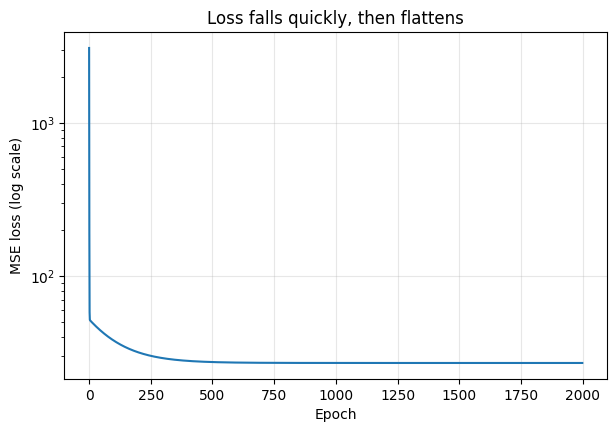

In [6]:
plt.plot(hist["loss"])
plt.yscale("log")
plt.xlabel("Epoch"); plt.ylabel("MSE loss (log scale)")
plt.title("Loss falls quickly, then flattens")
plt.show()

**Observation:** the loss drops fast at first and then flattens. Early steps have a large gradient so the line moves a lot. Near the minimum the gradient is tiny, so steps become tiny too.

## 5. Experiment 1: learning rate

The learning rate controls the step size. Three cases:

| Case | Behaviour |
|---|---|
| Very small | Converges, but very slowly, and may not reach the best line in the epochs given |
| Appropriate | Converges smoothly |
| Very large | Overshoots the minimum on every step and **diverges** |

For this data we can even compute the largest stable learning rate. For a quadratic loss, gradient descent is stable only if $lr < 2/\lambda_{max}$, where $\lambda_{max}$ is the largest eigenvalue of the loss's Hessian.

In [7]:
H = 2 * np.array([[np.mean(hours ** 2), np.mean(hours)],
                  [np.mean(hours),      1.0]])
lam_max = np.linalg.eigvalsh(H).max()
print(f"Largest stable learning rate for this data ~ {2 / lam_max:.4f}")

Largest stable learning rate for this data ~ 0.0255


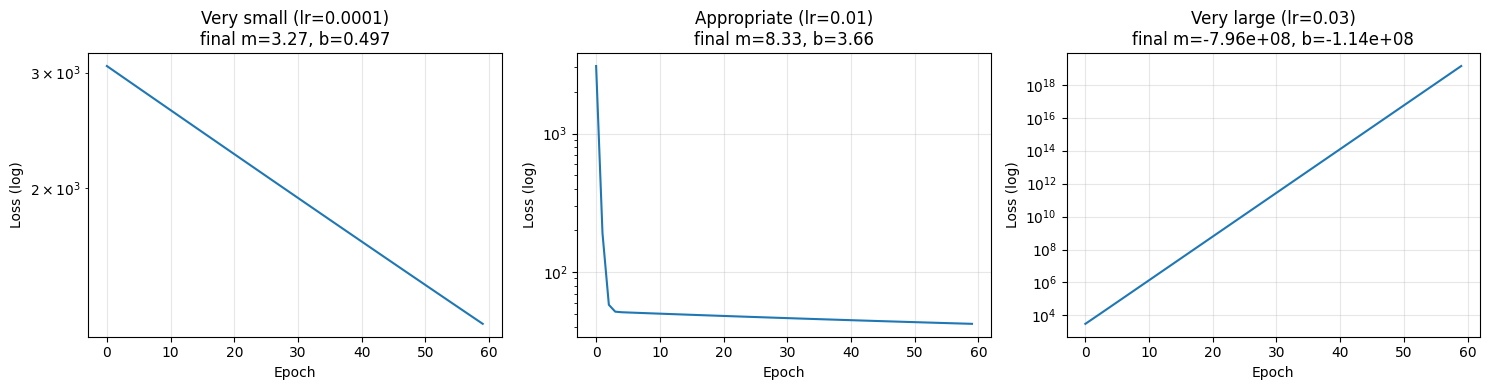

In [8]:
cases = {"Very small (lr=0.0001)": 0.0001,
         "Appropriate (lr=0.01)": 0.01,
         "Very large (lr=0.03)": 0.03}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, lr) in zip(axes, cases.items()):
    with np.errstate(all="ignore"):
        m, b, h = gradient_descent(hours, marks, lr=lr, epochs=60)
    ax.plot(h["loss"]); ax.set_yscale("log")
    ax.set_title(f"{name}\nfinal m={m:.3g}, b={b:.3g}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log)")
plt.tight_layout(); plt.show()

**Takeaway:** with `lr = 0.0001` the loss barely moves in 60 epochs, with `lr = 0.01` it falls steadily, and with `lr = 0.03` (just above the stable limit) the loss **grows** and the parameters blow up.

## 6. Experiment 2: how many iterations?

For a good learning rate, more iterations bring us closer to the best-fit line, but with **diminishing returns**.

 epochs         m         b    distance from sklearn
     10    8.6122    1.6920                11.860281
     50    8.3814    3.2987                10.022774
    100    8.1425    4.9617                 8.120899
    500    7.3120   10.7436                 1.508458
   1000    7.1456   11.9018                 0.183948
   2000    7.1229   12.0603                 0.002735
   5000    7.1225   12.0626                 0.000000


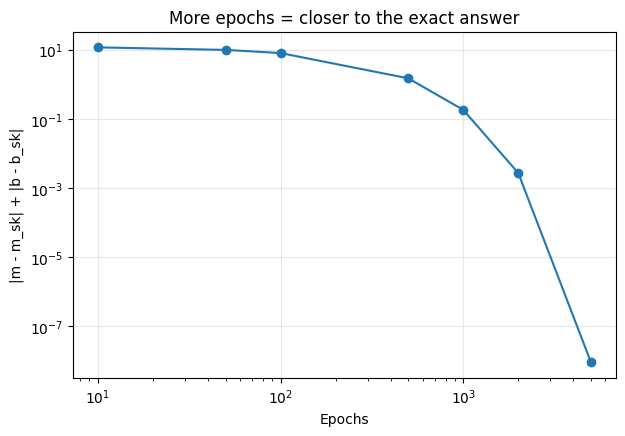

In [9]:
rows = []
for ep in [10, 50, 100, 500, 1000, 2000, 5000]:
    m, b, _ = gradient_descent(hours, marks, lr=0.01, epochs=ep)
    rows.append((ep, m, b, abs(m - m_sk) + abs(b - b_sk)))

print(f"{'epochs':>7} {'m':>9} {'b':>9} {'distance from sklearn':>24}")
for ep, m, b, d in rows:
    print(f"{ep:>7} {m:>9.4f} {b:>9.4f} {d:>24.6f}")

plt.plot([r[0] for r in rows], [r[3] for r in rows], marker="o")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Epochs"); plt.ylabel("|m - m_sk| + |b - b_sk|")
plt.title("More epochs = closer to the exact answer")
plt.show()

**Takeaway:** the gap shrinks steadily with more epochs, but it never reaches exactly zero. Gradient descent gets *arbitrarily close*, while the closed-form solution is exact. The "more iterations is better" rule holds here because the loss has a single minimum and the learning rate is stable. It does **not** hold for a bad learning rate (Experiment 1), and for neural networks more training can cause overfitting.

## 7. Feature scaling: a practical trick

With raw hours (1 to 10), the loss surface is a long narrow valley, so `m` and `b` converge at very different speeds and we needed ~2000 epochs. Standardising the feature makes the valley round, and convergence is fast with a much larger learning rate.

Scaled GD, 100 epochs, converted back: m = 7.1225, b = 12.0626
sklearn                              : m = 7.1225, b = 12.0626


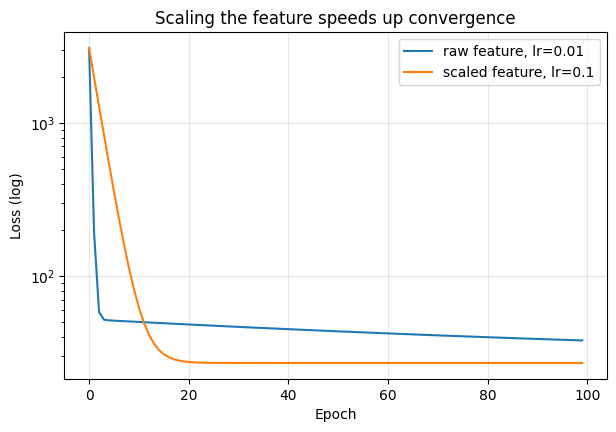

In [10]:
mu, sd = hours.mean(), hours.std()
hours_s = (hours - mu) / sd

m_s, b_s, hist_s = gradient_descent(hours_s, marks, lr=0.1, epochs=100)

# convert back to the original units
m_back = m_s / sd
b_back = b_s - m_s * mu / sd

print(f"Scaled GD, 100 epochs, converted back: m = {m_back:.4f}, b = {b_back:.4f}")
print(f"sklearn                              : m = {m_sk:.4f}, b = {b_sk:.4f}")

plt.plot(hist["loss"][:100], label="raw feature, lr=0.01")
plt.plot(hist_s["loss"], label="scaled feature, lr=0.1")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (log)")
plt.title("Scaling the feature speeds up convergence")
plt.legend(); plt.show()

## 8. Conclusions

- **Gradient descent** finds good parameters by repeatedly moving them against the gradient of the loss.
- It recovers the same line as scikit-learn's closed-form solution (`m` and `b` match to several decimals).
- **Learning rate matters most:** too small is slow, too large diverges.
- **More epochs help**, with diminishing returns, as long as training is stable.
- **Feature scaling** makes convergence much faster.

### Why this matters beyond linear regression
Linear regression has an exact solution, so we don't need gradient descent for it. We used it here because we can *verify* the result. Most models do not have a closed-form solution (logistic regression, neural networks, and the large language models behind AI agents), and they are trained with variants of this same loop: compute the loss, compute gradients, and update the parameters. The optimizers used in practice (SGD, Adam) are refinements of the update rule you just built.

### Possible extensions
- Stochastic and mini-batch gradient descent
- Multiple features (vectorised version with matrices)
- Gradient descent for logistic regression
- Momentum and Adam optimizers